[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter5_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 5: Conditional volatility, ARCH and GARCH

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Stylised facts of daily returns (S&P 500, BET, EUR/RON, Bitcoin); the ACF of squared returns; the ARCH-LM test.
- The mean model of Chapter 2 and its residuals; ARCH(1), ARCH(q) and GARCH(1,1); persistence, IGARCH and EWMA.
- Maximum-likelihood estimation with the `arch` package; Student-t and skewed-t innovations; AR(1)-GARCH(1,1).
- Asymmetry (GJR-GARCH, EGARCH, news impact curves); diagnostics; multi-step forecasts; QLIKE and the Diebold–Mariano test; VaR 1%.
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 6; Tsay (2010), *Analysis of Financial Time Series*, Ch. 3; Bollerslev (1986).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (ARCH/GARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$, `returns(k)` with `k` in `'sp500'`, `'bet'`, `'eurron'`, `'btc'`.
- ARCH-LM: regress $\hat\varepsilon_t^2$ on a constant and $q$ of its lags; $\mathrm{LM} = nR^2 \sim \chi^2(q)$: `arch_lm(x, q)`.
- GARCH(1,1): $\sigma_t^2 = \omega + \alpha\varepsilon_{t-1}^2 + \beta\sigma_{t-1}^2$; `fit(r, vol, dist, o, mean)` wraps `arch_model`; EUR/RON is estimated on $10\,r_t$ (`SCALE`) and `par`, `sig`, `summary` convert the results back to %.

In [6]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
SEED = 2026
ASSETS = ['sp500', 'bet', 'eurron', 'btc']
NAME = {'sp500': 'S&P 500', 'bet': 'BET', 'eurron': 'EUR/RON', 'btc': 'Bitcoin'}
START = {'sp500': '2000-01-01', 'bet': '2000-01-01', 'eurron': None, 'btc': None}
COLORS = {'sp500': '#1A3A6E', 'bet': '#CD0000', 'eurron': '#2E7D32', 'btc': '#B5853F'}
SCALE = {'eurron': 10}
EPISODES = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-15', '2020-05-31')}
OOS_START = '2015-01-01'
REFIT = 250
LAMBDA = 0.94
ALPHA_VAR = 0.01
LB_LAGS = 10
ARCH_LAGS = 5
IG = 0.9995
TERM_DATES = ['2017-11-03', '2020-03-16']


def returns(k, start=None, end=None):
    """Daily log returns in % on the series' own calendar."""
    r = log_returns(k, start or START.get(k)) if end is None else log_returns(k, start or START.get(k), end)
    return r.rename(k)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def acf_vals(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, lags=LB_LAGS, dof=0):
    """Ljung-Box Q(lags) and its p-value (chi-square with lags - dof degrees of freedom)."""
    lb = acorr_ljungbox(pd.Series(np.asarray(x, float)).dropna(), lags=[lags], model_df=dof)
    return float(lb['lb_stat'].iloc[0]), float(lb['lb_pvalue'].iloc[0])


def arch_lm(x, q=ARCH_LAGS):
    """Engle's (1982) ARCH-LM test: regress e_t^2 on a constant and e_{t-1}^2, ..., e_{t-q}^2 (e_t = x_t - mean);
    LM = n R^2 ~ chi-square(q) under no ARCH effects (n = number of regression observations)."""
    e2 = (np.asarray(x, float) - np.mean(x)) ** 2
    y = e2[q:]
    X = np.column_stack([np.ones(len(y))] + [e2[q - j:len(e2) - j] for j in range(1, q + 1)])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    r2 = 1 - np.sum(u ** 2) / np.sum((y - y.mean()) ** 2)
    lm = len(y) * r2
    return {'lm': float(lm), 'r2': float(r2), 'n': len(y), 'p': float(stats.chi2.sf(lm, q)),
            'crit': float(stats.chi2.ppf(0.95, q)), 'b': [float(v) for v in b]}


def fit(r, vol='GARCH', dist='t', o=0, p=1, q=1, mean='Constant', lags=1, last_obs=None, cov_type='robust'):
    """ML estimation with the arch package: constant or AR(lags) mean; GARCH (o = 0), GJR-GARCH (o = 1), EGARCH,
    ARCH(p). The series is multiplied by SCALE (EUR/RON: 10) and the result remembers the factor in res.sc."""
    sc = SCALE.get(r.name, 1)
    kw = dict(mean=mean, lags=lags if mean == 'AR' else 0, dist=dist, rescale=False)
    if vol == 'ARCH':
        am = arch_model(sc * r, vol='ARCH', p=p, **kw)
    elif vol == 'EGARCH':
        am = arch_model(sc * r, vol='EGARCH', p=1, o=1, q=1, **kw)
    else:
        am = arch_model(sc * r, vol='GARCH', p=p, o=o, q=q, **kw)
    res = am.fit(disp='off', last_obs=last_obs, cov_type=cov_type, options={'maxiter': 2000})
    res.sc = sc
    return res


def par(res):
    """Parameters in % units (the estimation scale removed): mu and Const / sc, omega / sc^2 (GARCH, GJR, ARCH)."""
    p = res.params.copy()
    for n in p.index:
        if n in ('mu', 'Const'):
            p[n] = p[n] / res.sc
        elif n == 'omega' and res.model.volatility.__class__.__name__ != 'EGARCH':
            p[n] = p[n] / res.sc ** 2
    return p


def sig(res):
    """Conditional volatility in %."""
    return res.conditional_volatility / res.sc


def persistence(res):
    """alpha + beta (GARCH), alpha + beta + gamma/2 (GJR with symmetric innovations), beta (EGARCH)."""
    p = res.params
    if res.model.volatility.__class__.__name__ == 'EGARCH':
        return float(p['beta[1]'])
    return float(sum(v for n, v in p.items() if n.startswith(('alpha', 'beta'))) + 0.5 * p.get('gamma[1]', 0.0))


def half_life(pers):
    """Days after which half of a variance shock has disappeared: ln 0.5 / ln(persistence)."""
    return float(np.log(0.5) / np.log(pers)) if 0 < pers < 1 else float('inf')


def summary(res, r):
    """Parameters and robust standard errors in % units, persistence, half-life, long-run and sample volatility."""
    p = par(res)
    se = res.std_err.copy()
    for n in se.index:
        if n in ('mu', 'Const'):
            se[n] = se[n] / res.sc
        elif n == 'omega':
            se[n] = se[n] / res.sc ** 2
    pers = persistence(res)
    ppy = periods_per_year(r)
    adj = res.nobs * np.log(res.sc)               # log-likelihood of r_t = log-likelihood of sc r_t + n ln sc
    out = {'n': int(res.nobs), 'first': r.index[0].date().isoformat(), 'ppy': float(ppy),
           'params': {k: float(v) for k, v in p.items()}, 'se': {k: float(v) for k, v in se.items()},
           'loglik': float(res.loglikelihood + adj), 'aic': float(res.aic - 2 * adj), 'bic': float(res.bic - 2 * adj),
           'k': int(len(p)), 'pers': pers, 'hl': half_life(pers), 'vol_sample': float(r.std() * np.sqrt(ppy))}
    if 'omega' in p and res.model.volatility.__class__.__name__ != 'EGARCH' and pers < IG:
        uv = p['omega'] / (1 - pers)
        out['uv'] = float(uv)
        out['vol_lr'] = float(np.sqrt(uv * ppy))
    return out


def ols_ar1(r):
    """AR(1) for the mean by OLS: r_t = c + phi r_{t-1} + e_t; coefficients, classic and HAC-robust t statistics."""
    y, x = r.values[1:], r.values[:-1]
    X = sm.add_constant(x)
    o = sm.OLS(y, X).fit()
    h = sm.OLS(y, X).fit(cov_type='HC0')
    return {'c': float(o.params[0]), 'phi': float(o.params[1]), 'se': float(o.bse[1]), 'se_robust': float(h.bse[1]),
            'resid': pd.Series(o.resid, index=r.index[1:])}


def ar_order(r, pmax=5):
    """AR(p) for the mean with constant variance, p = 0..pmax chosen by BIC on the same observations."""
    bic = {}
    for p in range(pmax + 1):
        am = arch_model(r * SCALE.get(r.name, 1), mean='AR' if p else 'Constant', lags=p, vol='Constant',
                        hold_back=pmax, rescale=False)
        bic[p] = float(am.fit(disp='off').bic)
    return min(bic, key=bic.get), bic


def ewma_variance(r, lam=LAMBDA, init=250):
    """EWMA variance forecast for day t made at t-1: h_t = lam h_{t-1} + (1 - lam) r_{t-1}^2 (zero mean)."""
    x = np.asarray(r, float)
    h = np.empty(len(x))
    h[0] = np.mean(x[:init] ** 2)
    for t in range(1, len(x)):
        h[t] = lam * h[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(h, index=r.index)


def news_impact(res, eps, s2bar):
    """sigma_t^2 as a function of the shock eps_{t-1}, with sigma_{t-1}^2 fixed at s2bar (Engle and Ng, 1993);
    for series estimated without scaling (SCALE = 1)."""
    p = res.params
    if res.model.volatility.__class__.__name__ == 'EGARCH':
        z = eps / np.sqrt(s2bar)
        return np.exp(p['omega'] + p['alpha[1]'] * (np.abs(z) - np.sqrt(2 / np.pi)) + p['gamma[1]'] * z
                      + p['beta[1]'] * np.log(s2bar))
    return p['omega'] + (p['alpha[1]'] + p.get('gamma[1]', 0.0) * (eps < 0)) * eps ** 2 + p['beta[1]'] * s2bar


def sign_bias_test(z, eps):
    """Engle-Ng (1993) sign-bias tests: z_t^2 on a constant, S-_{t-1}, S-_{t-1} eps_{t-1}, S+_{t-1} eps_{t-1};
    t statistics and the joint test T R^2 ~ chi2(3)."""
    d = pd.concat([pd.Series(np.asarray(z)), pd.Series(np.asarray(eps))], axis=1, keys=['z', 'e']).dropna()
    zz, e = d['z'].values, d['e'].values
    y = zz[1:] ** 2
    el = e[:-1]
    sneg = (el < 0).astype(float)
    X = np.column_stack([np.ones_like(el), sneg, sneg * el, (1 - sneg) * el])
    ols = sm.OLS(y, X).fit()
    joint = len(y) * ols.rsquared
    return {'sign_t': float(ols.tvalues[1]), 'neg_t': float(ols.tvalues[2]), 'pos_t': float(ols.tvalues[3]),
            'joint': float(joint), 'joint_p': float(stats.chi2.sf(joint, 3))}


def oos_forecasts(k, oos_start=OOS_START, refit=REFIT):
    """One-day-ahead variance forecasts on the out-of-sample period: GARCH-t and GJR-t re-estimated every `refit`
    observations on an expanding window (the forecast for day t uses data up to t-1), and EWMA; the one-day VaR 1% of
    GARCH-t and of EWMA-Normal (all in %)."""
    r = returns(k)
    sc = SCALE.get(k, 1)
    i0 = r.index.searchsorted(pd.Timestamp(oos_start))
    cols = {'garch': [], 'gjr': [], 'var_garch': []}
    for s in range(i0, len(r), refit):
        e = min(s + refit, len(r))
        fits = {}
        for lab, o in [('garch', 0), ('gjr', 1)]:
            am = arch_model(sc * r.iloc[:e], mean='Constant', vol='GARCH', p=1, o=o, q=1, dist='t', rescale=False)
            res = am.fit(disp='off', last_obs=r.index[s], options={'maxiter': 2000})
            fixed = am.fix(res.params)
            cols[lab].append(fixed.conditional_volatility.iloc[s:e] ** 2 / sc ** 2)
            fits[lab] = res.params
        p = fits['garch']
        q = stats.t.ppf(ALPHA_VAR, p['nu']) * np.sqrt((p['nu'] - 2) / p['nu'])
        cols['var_garch'].append(-(p['mu'] / sc + np.sqrt(cols['garch'][-1]) * q))
    df = pd.DataFrame({c: pd.concat(v) for c, v in cols.items()})
    df['ewma'] = ewma_variance(r).loc[df.index]
    df['var_ewma'] = -np.sqrt(df['ewma']) * stats.norm.ppf(ALPHA_VAR)
    df['r'] = r.loc[df.index]
    return df


def qlike(proxy, h):
    """QLIKE loss (Patton, 2011), written as proxy / h + ln h: it differs from proxy / h - ln(proxy / h) - 1 only by a
    term that does not depend on the forecast, and it allows a zero proxy."""
    return proxy / h + np.log(h)


def dm_test(la, lb, lags=5):
    """Diebold-Mariano: d = L_a - L_b; HAC (Newey-West) t statistic of the mean of d (negative: model a better)."""
    d = np.asarray(la) - np.asarray(lb)
    ols = sm.OLS(d, np.ones_like(d)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    t = float(ols.tvalues[0])
    return {'mean': float(d.mean()), 't': t, 'p': float(2 * stats.norm.sf(abs(t)))}

## 1. Stylised facts

- Moments, Ljung–Box on returns and squared returns, ARCH-LM; the four series; their ACFs.

,n,sd (%),skewness,kurtosis,Q(10) r,Q(10) r^2,ARCH-LM(5)
sp500,6714.0,1.213,-0.348,13.666,96.263,6132.817,1683.860
bet,6670.0,1.399,-0.653,14.063,108.018,2439.975,981.515
eurron,5352.0,0.279,0.725,18.139,221.658,2420.142,871.180
btc,4384.0,3.485,-0.705,14.958,20.178,212.745,114.666


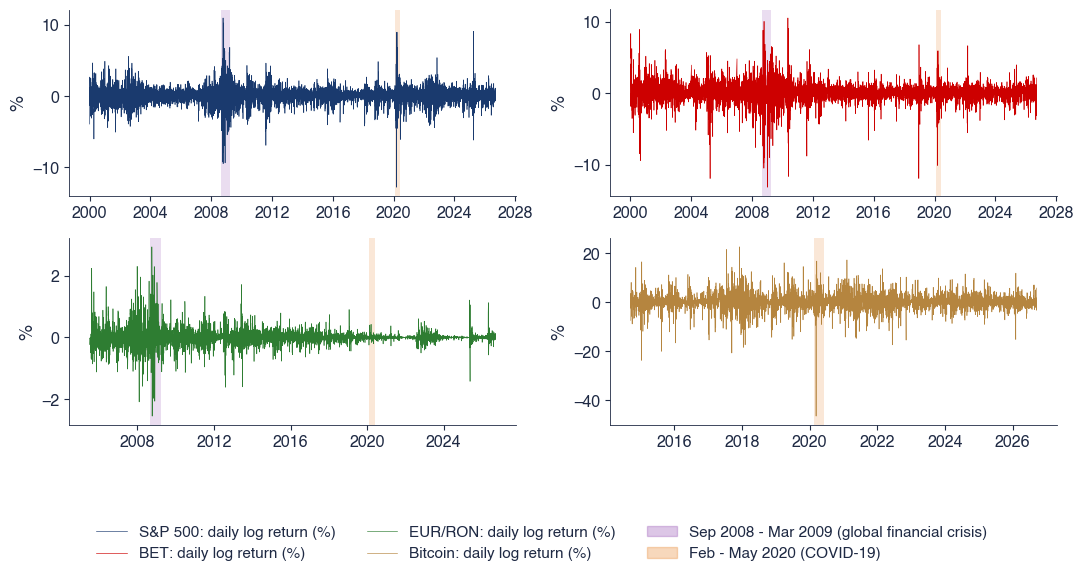

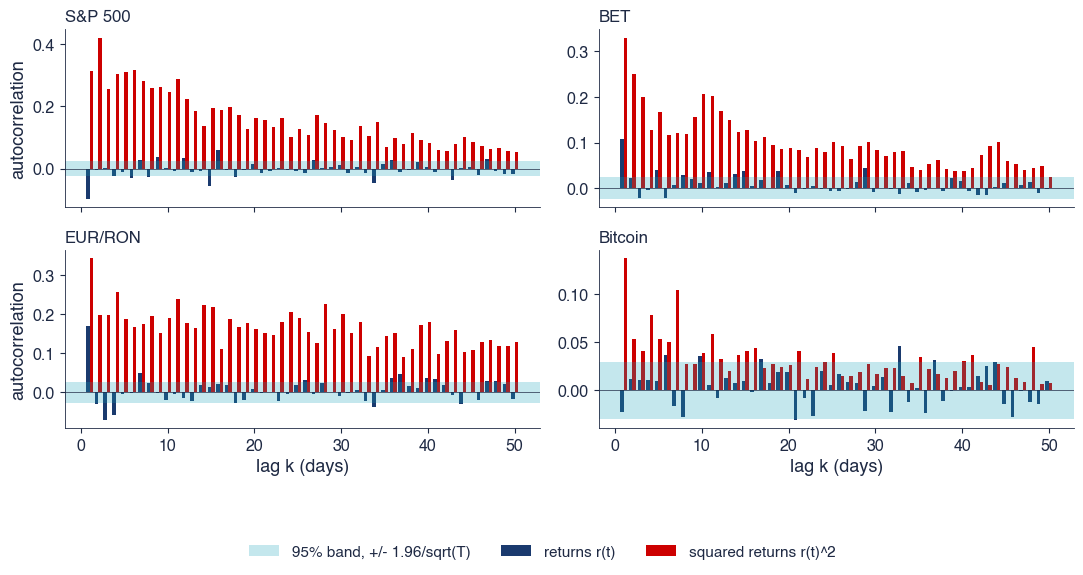

{'sp500': {'band': 0.02392023284731494,
  'r2_1': 0.31316071975401993,
  'r2_10': 0.24739943794928926,
  'r2_50': 0.05276684699766004,
  'r_1': -0.09858040590252937,
  'out_r2': 50,
  'out_r': 15},
 'bet': {'band': 0.02399900047893674,
  'r2_1': 0.33043644577381215,
  'r2_10': 0.20599918206970363,
  'r2_50': 0.02528210506124764,
  'r_1': 0.10882832616947716,
  'out_r2': 50,
  'out_r': 8},
 'eurron': {'band': 0.0267915610388766,
  'r2_1': 0.342259732478871,
  'r2_10': 0.18964795863529332,
  'r2_50': 0.12926003623416146,
  'r_1': 0.1697143325241145,
  'out_r2': 50,
  'out_r': 15},
 'btc': {'band': 0.02960198257317867,
  'r2_1': 0.13668910961302372,
  'r2_10': 0.039099015298861034,
  'r2_50': 0.007253103861348668,
  'r_1': -0.02230531534360892,
  'out_r2': 19,
  'out_r': 6}}

In [7]:
def stylised_table(names=ASSETS):
    """Moments, autocorrelations of r, r^2 and |r| at lag 1, Ljung-Box Q(10) of r and r^2, ARCH-LM(5)."""
    out = {}
    for k in names:
        r = returns(k)
        x = r.values
        ppy = periods_per_year(r)
        jb = stats.jarque_bera(x)
        out[k] = {'n': len(x), 'first': r.index[0].date().isoformat(), 'last': r.index[-1].date().isoformat(),
                  'mean': float(x.mean()), 'sd': float(x.std(ddof=1)), 'vol': float(x.std(ddof=1) * np.sqrt(ppy)),
                  'ppy': float(ppy), 'skew': float(stats.skew(x)), 'kurt': float(stats.kurtosis(x, fisher=False)),
                  'jb': float(jb.statistic), 'min': float(x.min()), 'max': float(x.max()),
                  'date_min': r.idxmin().date().isoformat(), 'date_max': r.idxmax().date().isoformat(),
                  'rho_r': float(acf_vals(x, 1)[0]), 'rho_r2': float(acf_vals(x ** 2, 1)[0]),
                  'rho_abs': float(acf_vals(np.abs(x), 1)[0]), 'lb_r': ljung_box(x), 'lb_r2': ljung_box(x ** 2),
                  'arch': arch_lm(x)}
    return out


def fig_returns(names=ASSETS, save_it=True):
    """Daily log returns of the four series with the 2008 and 2020 episodes shaded."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 5.2))
    out = {}
    for ax, k in zip(axes.ravel(), names):
        r = returns(k)
        ax.plot(r.index, r.values, color=COLORS[k], lw=0.45, label=f'{NAME[k]}: daily log return (%)')
        for (a, b), c in zip(EPISODES.values(), [st.Purple, st.Orange]):
            if pd.Timestamp(a) > r.index[0]:
                ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=0.18, lw=0)
        ax.set_ylabel('%')
        out[k] = {f'sd{e}': float(r.loc[a:b].std()) for e, (a, b) in EPISODES.items() if pd.Timestamp(a) > r.index[0]}
        out[k]['sd2017'] = float(r.loc['2017-01-01':'2017-12-31'].std())
        out[k]['sd_all'] = float(r.std())
    h, l = [], []
    for ax in axes.ravel():
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            h.append(hh)
            l.append(ll)
    h += [plt.Rectangle((0, 0), 1, 1, color=st.Purple, alpha=0.3), plt.Rectangle((0, 0), 1, 1, color=st.Orange, alpha=0.3)]
    l += ['Sep 2008 - Mar 2009 (global financial crisis)', 'Feb - May 2020 (COVID-19)']
    st.fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.085, 1, 1))
    save('tsa_ch5_returns', save_it)
    return out


def fig_acf_squares(names=ASSETS, lags=50, save_it=True):
    """ACF of returns and of squared returns, lags 1-50, with the i.i.d. 95% band, for the four series."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 5.4), sharex=True)
    out = {}
    j = np.arange(1, lags + 1)
    for ax, k in zip(axes.ravel(), names):
        x = returns(k).values
        a_r, a_2 = acf_vals(x, lags), acf_vals(x ** 2, lags)
        band = 1.96 / np.sqrt(len(x))
        ax.bar(j - 0.2, a_r, width=0.4, color=st.MainBlue, label='returns r(t)')
        ax.bar(j + 0.2, a_2, width=0.4, color=st.IDAred, label='squared returns r(t)^2')
        ax.axhspan(-band, band, color=st.Teal, alpha=0.25, lw=0, label='95% band, +/- 1.96/sqrt(T)')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_title(NAME[k], loc='left', fontsize=12)
        out[k] = {'band': float(band), 'r2_1': float(a_2[0]), 'r2_10': float(a_2[9]), 'r2_50': float(a_2[-1]),
                  'r_1': float(a_r[0]), 'out_r2': int(np.sum(np.abs(a_2) > band)), 'out_r': int(np.sum(np.abs(a_r) > band))}
    for ax in axes[1]:
        ax.set_xlabel('lag k (days)')
    for ax in axes[:, 0]:
        ax.set_ylabel('autocorrelation')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch5_acf_squares', save_it)
    return out


S = stylised_table()
display(pd.DataFrame({k: {'n': v['n'], 'sd (%)': v['sd'], 'skewness': v['skew'], 'kurtosis': v['kurt'], 'Q(10) r': v['lb_r'][0], 'Q(10) r^2': v['lb_r2'][0], 'ARCH-LM(5)': v['arch']['lm']} for k, v in S.items()}).T.round(3))
fig_returns(save_it=False)
fig_acf_squares(save_it=False)

## 2. The mean model leaves ARCH effects

- An AR(1) for the BET returns; ARCH-LM step by step; residual ACFs before and after AR(1)-GARCH(1,1)-t.

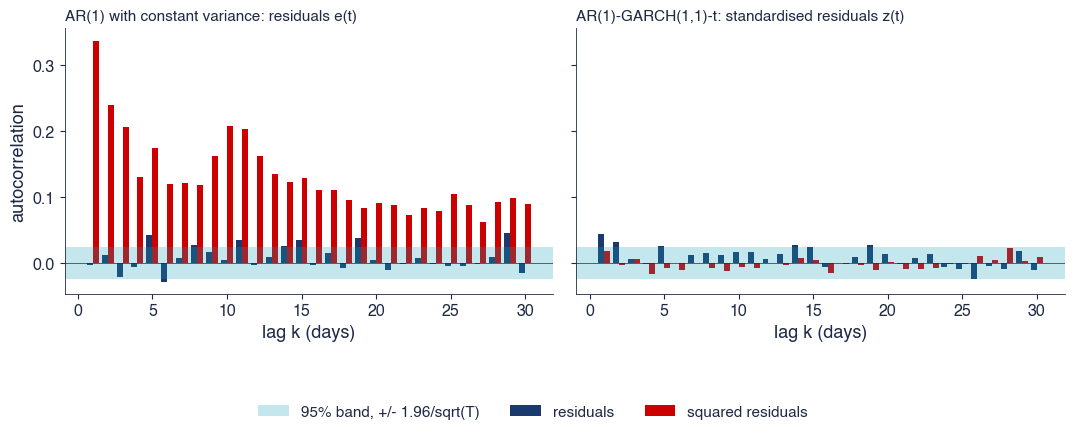

AR order by BIC: 1  phi = 0.109
ARCH-LM on the AR(1) residuals: R2 = 0.1526  n = 6664  LM = n R2 = 1017.1  5% critical value = 11.07


In [8]:
def fig_arma_resid(k='bet', lags=30, save_it=True):
    """Left: ACF of the residuals of an AR(1) mean model and of their squares. Right: ACF of the standardised
    residuals of AR(1)-GARCH(1,1)-t and of their squares."""
    r = returns(k)
    o = ols_ar1(r)
    e = o['resid'].values
    res = fit(r, mean='AR', dist='t')
    z = res.std_resid.dropna().values
    j = np.arange(1, lags + 1)
    band = 1.96 / np.sqrt(len(e))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
    for ax, (a, b), t in [(axes[0], (e, e ** 2), 'AR(1) with constant variance: residuals e(t)'),
                          (axes[1], (z, z ** 2), 'AR(1)-GARCH(1,1)-t: standardised residuals z(t)')]:
        ax.bar(j - 0.2, acf_vals(a, lags), width=0.4, color=st.MainBlue, label='residuals')
        ax.bar(j + 0.2, acf_vals(b, lags), width=0.4, color=st.IDAred, label='squared residuals')
        ax.axhspan(-band, band, color=st.Teal, alpha=0.25, lw=0, label='95% band, +/- 1.96/sqrt(T)')
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_title(t, loc='left', fontsize=11)
        ax.set_xlabel('lag k (days)')
    axes[0].set_ylabel('autocorrelation')
    h, l = axes[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h, l, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch5_arma_resid', save_it)
    p_bic, bic = ar_order(r)
    return {'p_bic': int(p_bic), 'phi': o['phi'], 'phi_se': o['se'], 'phi_se_robust': o['se_robust'], 'c': o['c'],
            'lb_e': ljung_box(e, dof=1), 'lb_e2': ljung_box(e ** 2), 'archlm_e': arch_lm(e),
            'lb_z': ljung_box(z, dof=1), 'lb_z2': ljung_box(z ** 2), 'archlm_z': arch_lm(z),
            'acf_e2_1': float(acf_vals(e ** 2, 1)[0]), 'acf_z2_1': float(acf_vals(z ** 2, 1)[0])}


A = fig_arma_resid(save_it=False)
print('AR order by BIC:', A['p_bic'], ' phi =', round(A['phi'], 3))
print('ARCH-LM on the AR(1) residuals: R2 =', round(A['archlm_e']['r2'], 4), ' n =', A['archlm_e']['n'], ' LM = n R2 =', round(A['archlm_e']['lm'], 1), ' 5% critical value =', round(A['archlm_e']['crit'], 2))

## 3. ARCH and GARCH by simulation; the likelihood

- Paths with the same unconditional variance; the ARCH(1) log-likelihood for two sample sizes; the ridge of the GARCH(1,1) likelihood.

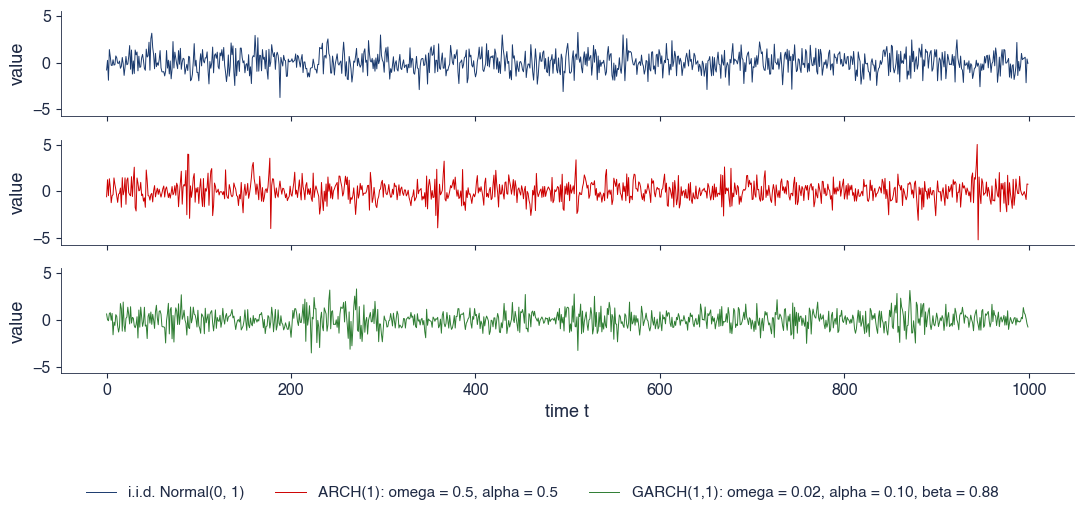

{'i.i.d. Normal(0, 1)': {'sd': 1.0304556065650603, 'kurt': 3.123049004729069, 'max_abs': 3.747413858130894, 'acf2_1': -0.030009910880500677}, 'ARCH(1)': {'sd': 1.0233520220966699, 'kurt': 4.910973401188952, 'max_abs': 5.211144268406423, 'acf2_1': 0.5088330212224601}, 'GARCH(1,1)': {'sd': 0.9274374031785692, 'kurt': 3.740525282563708, 'max_abs': 3.543086950257758, 'acf2_1': 0.06929476661971908}}


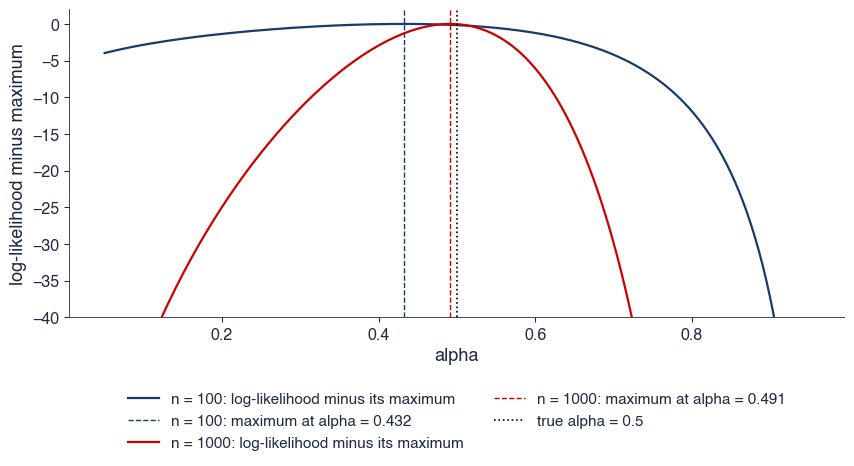

{'100': {'alpha_hat': 0.4321708014832945, 'se': 0.12654232891838452}, '1000': {'alpha_hat': 0.4914830947353353, 'se': 0.035046208171455616}}


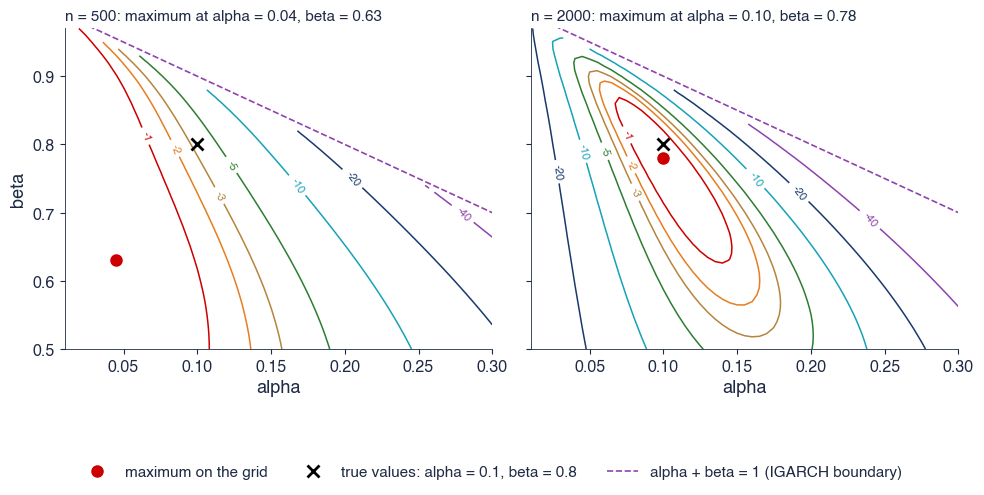

{'500': {'a_hat': 0.045, 'b_hat': 0.63}, '2000': {'a_hat': 0.09999999999999998, 'b_hat': 0.78}}


In [9]:
def simulate_garch(n, omega, alpha, beta=0.0, burn=500, seed=SEED, dist='normal', nu=5.0):
    """eps_t = sigma_t z_t, sigma_t^2 = omega + alpha eps_{t-1}^2 + beta sigma_{t-1}^2 (beta = 0: ARCH(1));
    z_t standard Normal or standardised Student-t; returns (eps, sigma)."""
    rng = np.random.default_rng(seed)
    m = n + burn
    z = rng.standard_normal(m) if dist == 'normal' else rng.standard_t(nu, m) * np.sqrt((nu - 2) / nu)
    s2 = np.empty(m)
    e = np.empty(m)
    s2[0] = omega / (1 - alpha - beta)
    e[0] = np.sqrt(s2[0]) * z[0]
    for t in range(1, m):
        s2[t] = omega + alpha * e[t - 1] ** 2 + beta * s2[t - 1]
        e[t] = np.sqrt(s2[t]) * z[t]
    return e[burn:], np.sqrt(s2[burn:])


def fig_simulated(n=1000, save_it=True):
    """Three paths with unconditional variance 1: i.i.d. Normal, ARCH(1) (omega = 0.5, alpha = 0.5) and
    GARCH(1,1) (omega = 0.02, alpha = 0.10, beta = 0.88, values typical of daily equity returns)."""
    rng = np.random.default_rng(SEED)
    paths = {'i.i.d. Normal(0, 1)': rng.standard_normal(n),
             'ARCH(1): omega = 0.5, alpha = 0.5': simulate_garch(n, 0.5, 0.5, 0.0, seed=SEED + 1)[0],
             'GARCH(1,1): omega = 0.02, alpha = 0.10, beta = 0.88': simulate_garch(n, 0.02, 0.10, 0.88, seed=SEED + 2)[0]}
    fig, axes = plt.subplots(3, 1, figsize=(11, 4.8), sharex=True, sharey=True)
    out = {}
    for ax, (lab, x), c in zip(axes, paths.items(), [st.MainBlue, st.IDAred, st.Forest]):
        ax.plot(np.arange(n), x, color=c, lw=0.7, label=lab)
        ax.set_ylabel('value')
        out[lab.split(':')[0]] = {'sd': float(np.std(x)), 'kurt': float(stats.kurtosis(x, fisher=False)),
                                  'max_abs': float(np.max(np.abs(x))), 'acf2_1': float(acf_vals(x ** 2, 1)[0])}
    axes[-1].set_xlabel('time t')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch5_simulated', save_it)
    return out


def arch1_loglik(alpha, x):
    """Conditional Gaussian log-likelihood of ARCH(1) with omega = 1 - alpha (unconditional variance 1):
    l(alpha) = sum_{t>=2} [-0.5 ln s2_t - 0.5 x_t^2 / s2_t] (constant dropped), s2_t = omega + alpha x_{t-1}^2."""
    s2 = (1 - alpha) + alpha * x[:-1] ** 2
    return float(np.sum(-0.5 * np.log(s2) - 0.5 * x[1:] ** 2 / s2))


def fig_lik_arch1(ns=(100, 1000), alpha0=0.5, save_it=True):
    """Log-likelihood of a simulated ARCH(1) (omega = alpha = 0.5) as a function of alpha, for two sample sizes;
    each curve minus its maximum; standard errors from the curvature at the maximum."""
    grid = np.linspace(0.05, 0.95, 181)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    for n, c in zip(ns, [st.MainBlue, st.IDAred]):
        x = simulate_garch(n, 1 - alpha0, alpha0, 0.0, seed=SEED + n)[0]
        ll = np.array([arch1_loglik(a, x) for a in grid])
        res = optimize.minimize_scalar(lambda a: -arch1_loglik(a, x), bounds=(0.001, 0.999), method='bounded')
        ax.plot(grid, ll - ll.max(), color=c, lw=1.6, label=f'n = {n}: log-likelihood minus its maximum')
        ax.axvline(res.x, color=c, ls='--', lw=1.0, label=f'n = {n}: maximum at alpha = {res.x:.3f}')
        h = 1e-4
        d2 = (arch1_loglik(res.x + h, x) - 2 * arch1_loglik(res.x, x) + arch1_loglik(res.x - h, x)) / h ** 2
        out[str(n)] = {'alpha_hat': float(res.x), 'se': float(1 / np.sqrt(-d2))}
    ax.axvline(alpha0, color='black', ls=':', lw=1.2, label=f'true alpha = {alpha0}')
    ax.set_ylim(-40, 2)
    ax.set_xlabel('alpha')
    ax.set_ylabel('log-likelihood minus maximum')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('tsa_ch5_lik_arch1', save_it)
    return out


def garch_loglik_vt(a, b, x, s2bar):
    """Gaussian GARCH(1,1) log-likelihood with variance targeting omega = (1 - a - b) s2bar."""
    om = (1 - a - b) * s2bar
    s2 = np.empty(len(x))
    s2[0] = s2bar
    for t in range(1, len(x)):
        s2[t] = om + a * x[t - 1] ** 2 + b * s2[t - 1]
    return float(np.sum(-0.5 * np.log(s2[1:]) - 0.5 * x[1:] ** 2 / s2[1:]))


def fig_lik_garch(ns=(500, 2000), save_it=True):
    """Contours of the log-likelihood of a simulated GARCH(1,1) (omega = 0.1, alpha = 0.1, beta = 0.8) over a grid of
    (alpha, beta), omega set by variance targeting, for n = 500 and n = 2000."""
    A = np.linspace(0.01, 0.30, 59)
    B = np.linspace(0.50, 0.97, 48)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharey=True)
    out = {}
    cols = [st.Purple, st.MainBlue, st.Teal, st.Forest, st.Amber, st.Orange, st.IDAred]
    for ax, n in zip(axes, ns):
        x = simulate_garch(n, 0.1, 0.1, 0.8, seed=SEED + 7)[0]
        s2bar = float(np.var(x))
        L = np.full((len(B), len(A)), np.nan)
        for i, b in enumerate(B):
            for j, a in enumerate(A):
                if a + b < 0.995:
                    L[i, j] = garch_loglik_vt(a, b, x, s2bar)
        i, j = np.unravel_index(np.nanargmax(L), L.shape)
        lv = np.nanmax(L) - np.array([40, 20, 10, 5, 3, 2, 1])
        cs = ax.contour(A, B, L, levels=lv, colors=cols, linewidths=1.1)
        ax.clabel(cs, fmt=lambda v, m=np.nanmax(L): f'{v - m:.0f}', fontsize=8)
        ax.plot(A[j], B[i], 'o', color=st.IDAred, ms=8, label='maximum on the grid')
        ax.plot(0.1, 0.8, 'x', color='black', ms=9, mew=2, label='true values: alpha = 0.1, beta = 0.8')
        ax.plot(A, 1 - A, color=st.Purple, ls='--', lw=1.2, label='alpha + beta = 1 (IGARCH boundary)')
        ax.set_xlim(A[0], A[-1])
        ax.set_ylim(B[0], B[-1])
        ax.set_title(f'n = {n}: maximum at alpha = {A[j]:.2f}, beta = {B[i]:.2f}', loc='left', fontsize=11)
        ax.set_xlabel('alpha')
        out[str(n)] = {'a_hat': float(A[j]), 'b_hat': float(B[i])}
    axes[0].set_ylabel('beta')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch5_lik_garch', save_it)
    return out


print(fig_simulated(save_it=False))
print(fig_lik_arch1(save_it=False))
print(fig_lik_garch(save_it=False))

## 4. Estimation by maximum likelihood

- ARCH(q) against GARCH(1,1); GARCH(1,1) step by step with scipy and with `arch`; classic and robust standard errors; three innovation distributions; QQ plots.

,k,loglik,aic,bic,sum_alpha,pers
ARCH(1),3.0,-10305.524,20617.048,20637.484,0.394,0.394
ARCH(5),7.0,-9340.529,18695.057,18742.741,0.816,0.816
ARCH(10),12.0,-9227.647,18479.295,18561.038,0.849,0.849
"GARCH(1,1)",4.0,-9217.992,18443.983,18471.231,0.121,0.980


,step by step,arch
mu,0.0614,0.0615
omega,0.0253,0.0254
alpha[1],0.1205,0.1206
beta[1],0.8600,0.8599


,classic SE,robust SE
mu,0.0098,0.0100
omega,0.0030,0.0048
alpha[1],0.0086,0.0118
beta[1],0.0091,0.0125


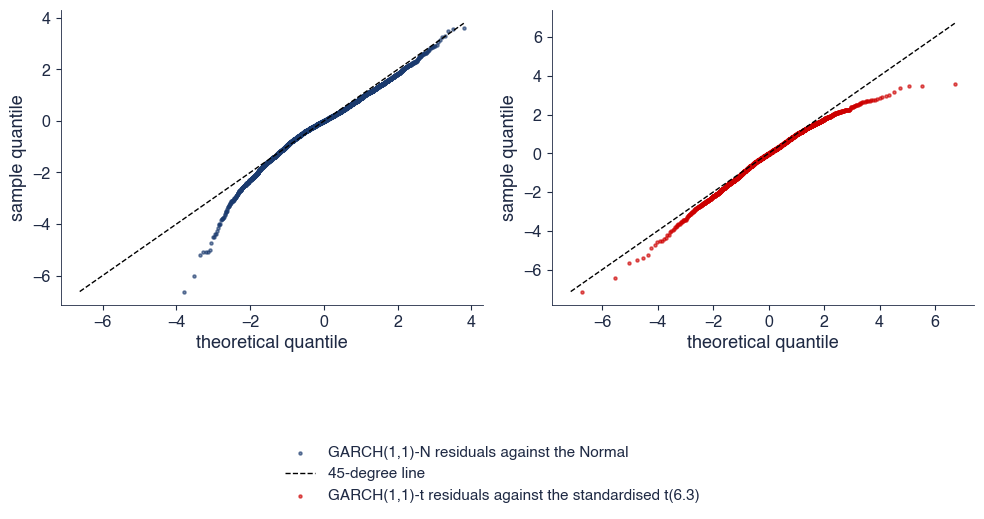

{'nu': 6.256190304034686,
 'q': {'GARCH(1,1)-N': {'q001': -4.814994199582458,
   'th001': -3.090232306167813},
  'GARCH(1,1)-t': {'q001': -4.790511893599644, 'th001': -4.191055602139561}}}

In [10]:
def garch11_negloglik(theta, x):
    """Minus the Gaussian log-likelihood of r_t = mu + eps_t, GARCH(1,1); sigma_1^2 = sample variance."""
    mu, om, a, b = theta
    if om <= 0 or a < 0 or b < 0 or a + b >= 1:
        return 1e10
    e = x - mu
    s2 = np.empty(len(x))
    s2[0] = np.var(x)
    for t in range(1, len(x)):
        s2[t] = om + a * e[t - 1] ** 2 + b * s2[t - 1]
    return 0.5 * np.sum(np.log(2 * np.pi) + np.log(s2) + e ** 2 / s2)


def fit_step_by_step(r):
    """Gaussian GARCH(1,1) by numerical optimisation of the log-likelihood (scipy, SLSQP, alpha + beta < 1), with
    classic standard errors from the inverse of the numerical Hessian."""
    x = np.asarray(r, float)
    v = np.var(x)
    th0 = np.array([x.mean(), 0.05 * v, 0.08, 0.90])
    bnds = [(None, None), (1e-6, None), (1e-6, 0.999), (1e-6, 0.999)]
    cons = [{'type': 'ineq', 'fun': lambda t: 0.9999 - t[2] - t[3]}]
    res = optimize.minimize(garch11_negloglik, th0, args=(x,), method='SLSQP', bounds=bnds, constraints=cons,
                            options={'maxiter': 1000, 'ftol': 1e-10})
    th = res.x
    from statsmodels.tools.numdiff import approx_hess
    H = approx_hess(th, garch11_negloglik, args=(x,))
    se = np.sqrt(np.diag(np.linalg.inv(H)))
    names = ['mu', 'omega', 'alpha[1]', 'beta[1]']
    return {'params': dict(zip(names, map(float, th))), 'se': dict(zip(names, map(float, se))), 'loglik': float(-res.fun)}


def arch_q_table(k='sp500'):
    """ARCH(1), ARCH(5), ARCH(10) and GARCH(1,1), all Gaussian: log-likelihood, AIC, BIC, sum of the ARCH terms."""
    r = returns(k)
    out = {}
    for lab, kw in [('ARCH(1)', dict(vol='ARCH', p=1)), ('ARCH(5)', dict(vol='ARCH', p=5)),
                    ('ARCH(10)', dict(vol='ARCH', p=10)), ('GARCH(1,1)', dict(vol='GARCH'))]:
        res = fit(r, dist='normal', **kw)
        p = res.params
        out[lab] = {'k': int(len(p)), 'loglik': float(res.loglikelihood), 'aic': float(res.aic), 'bic': float(res.bic),
                    'sum_alpha': float(sum(v for n, v in p.items() if n.startswith('alpha'))),
                    'pers': float(sum(v for n, v in p.items() if n.startswith(('alpha', 'beta'))))}
    return out


def estimation_sp500(k='sp500'):
    """S&P 500 GARCH(1,1): Normal innovations step by step and with arch (classic and robust standard errors);
    Student-t and skewed-t innovations with arch; kurtosis of returns and of standardised residuals."""
    r = returns(k)
    out = {'step': fit_step_by_step(r)}
    rn = fit(r, dist='normal')
    rc = fit(r, dist='normal', cov_type='classic')
    out['normal'] = summary(rn, r)
    out['normal']['se_classic'] = {n: float(v) for n, v in rc.std_err.items()}
    for d in ['t', 'skewt']:
        out[d] = summary(fit(r, dist=d), r)
    z = rn.std_resid.dropna()
    out['kurt_r'] = float(stats.kurtosis(r, fisher=False))
    out['kurt_z'] = float(stats.kurtosis(z, fisher=False))
    out['kurt_zt'] = float(stats.kurtosis(fit(r, dist='t').std_resid.dropna(), fisher=False))
    return out


def fig_qq(k='sp500', save_it=True):
    """QQ plots of the standardised residuals: GARCH-N against the Normal, GARCH-t against the standardised t."""
    r = returns(k)
    rn, rt = fit(r, dist='normal'), fit(r, dist='t')
    nu = rt.params['nu']
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
    out = {}
    for ax, res, lab, ppf, c in [(axes[0], rn, 'GARCH(1,1)-N residuals against the Normal', stats.norm.ppf, st.MainBlue),
                                 (axes[1], rt, f'GARCH(1,1)-t residuals against the standardised t({nu:.1f})',
                                  lambda u: stats.t.ppf(u, nu) * np.sqrt((nu - 2) / nu), st.IDAred)]:
        z = np.sort(res.std_resid.dropna().values)
        u = (np.arange(1, len(z) + 1) - 0.5) / len(z)
        qth = ppf(u)
        ax.scatter(qth, z, s=5, color=c, alpha=0.6, label=lab)
        lim = [min(qth.min(), z.min()), max(qth.max(), z.max())]
        ax.plot(lim, lim, color='black', lw=1.0, ls='--', label='45-degree line' if c == st.MainBlue else '_')
        ax.set_xlabel('theoretical quantile')
        ax.set_ylabel('sample quantile')
        out[lab.split()[0]] = {'q001': float(np.quantile(z, 0.001)), 'th001': float(ppf(0.001))}
    st.fig_legend_bottom(fig, ncol=1, y=0.0)
    fig.tight_layout(rect=(0, 0.14, 1, 1))
    save('tsa_ch5_qq', save_it)
    return {'nu': float(nu), 'q': out}


display(pd.DataFrame(arch_q_table()).T.round(3))
E = estimation_sp500()
display(pd.DataFrame({'step by step': E['step']['params'], 'arch': E['normal']['params']}).round(4))
display(pd.DataFrame({'classic SE': E['normal']['se_classic'], 'robust SE': E['normal']['se']}).round(4))
fig_qq(save_it=False)

## 5. GARCH(1,1)-t in four markets; EWMA against GARCH

- Persistence, half-life, long-run volatility; conditional volatility; the decay of a shock; the COVID-19 crash.

,omega,alpha,beta,nu,persistence,half-life,long-run vol,sample vol
sp500,0.015714,0.122573,0.872139,6.256190,0.994712,1.307335e+02,27.333552,19.233831
bet,0.044783,0.191625,0.799087,5.011248,0.990712,7.427768e+01,34.705389,22.106332
eurron,0.000005,0.123099,0.876901,4.196241,1.000000,inf,NaN,4.439018
btc,0.193692,0.108737,0.891263,3.180637,1.000000,2.044709e+11,NaN,66.614901


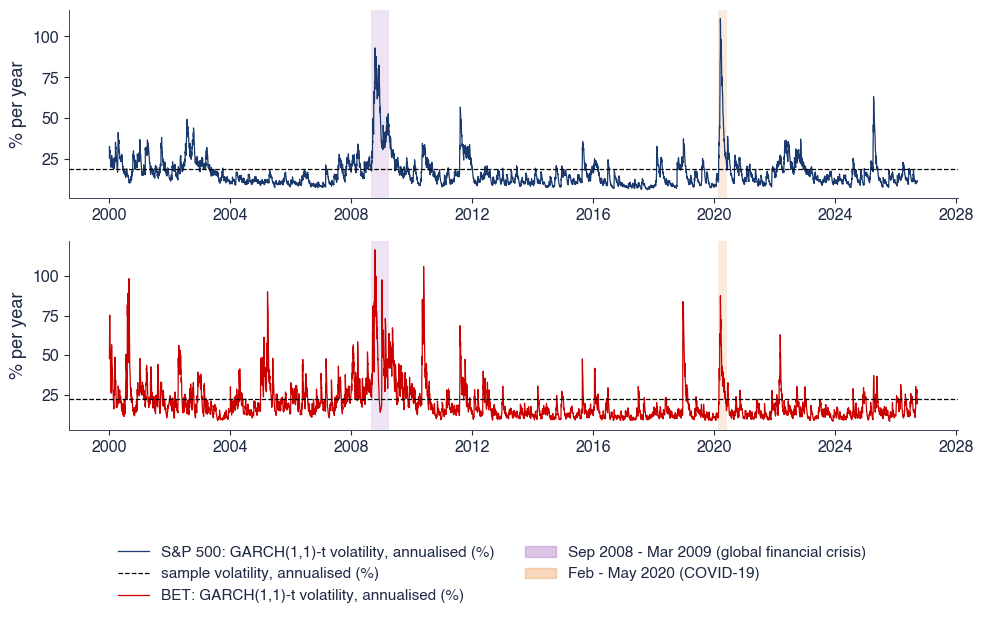

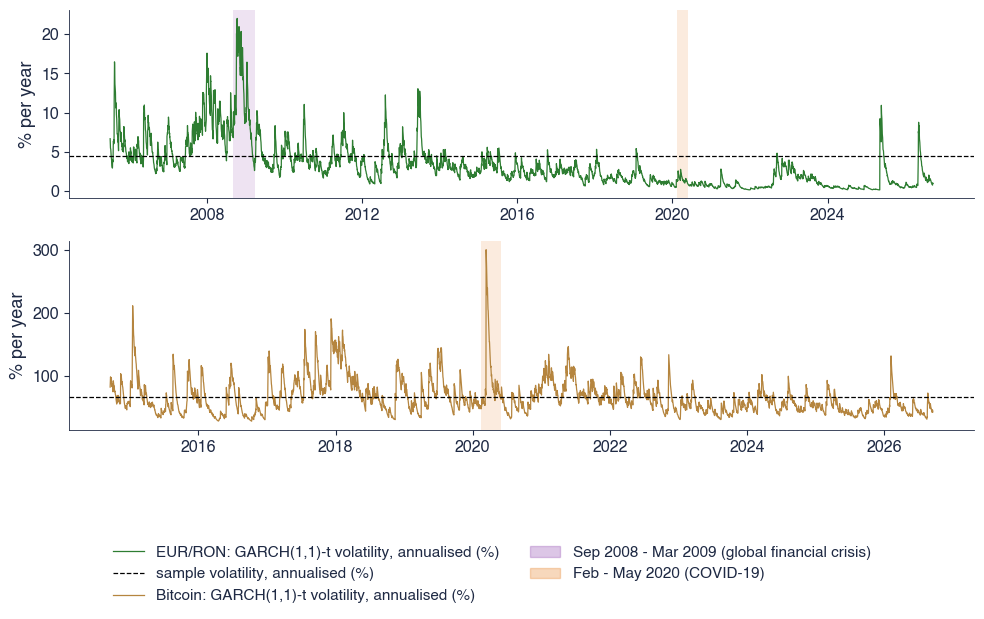

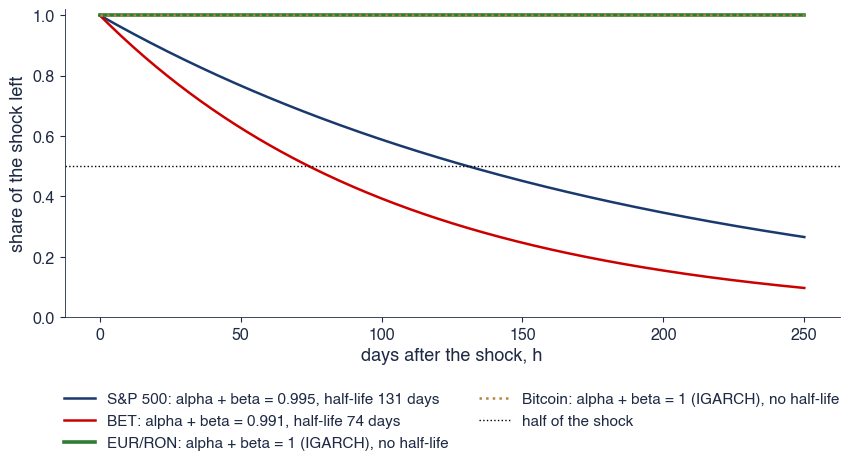

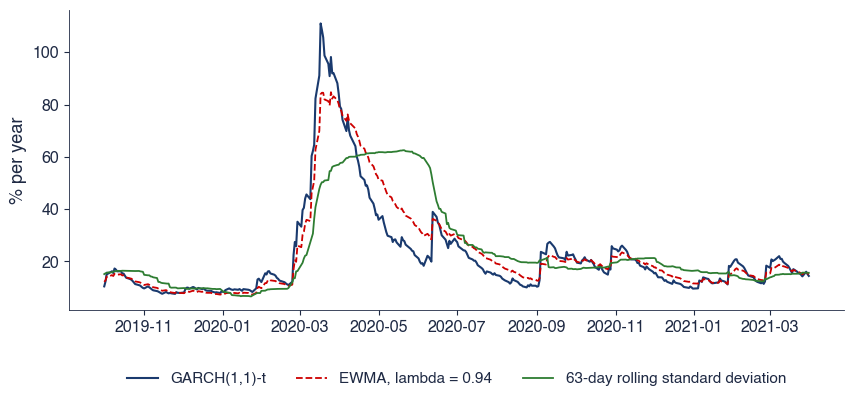

{'g_peak': 111.02616503718859,
 'g_dpeak': '2020-03-17',
 'e_peak': 84.7279555498158,
 'e_dpeak': '2020-03-25',
 'w_peak': 62.526829887096454,
 'w_dpeak': '2020-05-20',
 'g_jun': 27.94458365839785,
 'e_jun': 30.097592758492947,
 'w_jun': 31.80111717311134,
 'hl_ewma': 11.202305583621158}

In [11]:
def markets_table(names=ASSETS):
    """GARCH(1,1)-t for each series: parameters, robust standard errors, persistence, half-life, volatility."""
    return {k: summary(fit(returns(k), dist='t'), returns(k)) for k in names}


def fig_vol(names=('sp500', 'bet'), fname='tsa_ch5_vol_sp500_bet', save_it=True):
    """Annualised GARCH(1,1)-t conditional volatility, with the 2008 and 2020 episodes shaded."""
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 5.4))
    out = {}
    for ax, k in zip(np.atleast_1d(axes), names):
        r = returns(k)
        res = fit(r, dist='t')
        ann = np.sqrt(periods_per_year(r))
        v = sig(res) * ann
        ax.plot(v.index, v.values, color=COLORS[k], lw=0.9, label=f'{NAME[k]}: GARCH(1,1)-t volatility, annualised (%)')
        ax.axhline(r.std() * ann, color='black', ls='--', lw=0.9,
                   label='sample volatility, annualised (%)' if k == names[0] else '_')
        for (a, b), c in zip(EPISODES.values(), [st.Purple, st.Orange]):
            if pd.Timestamp(a) > r.index[0]:
                ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=0.15, lw=0)
        ax.set_ylabel('% per year')
        out[k] = {'last': float(v.iloc[-1]), 'max': float(v.max()), 'date_max': v.idxmax().date().isoformat(),
                  'min': float(v.min()), 'median': float(v.median())}
        for e, (a, b) in EPISODES.items():
            w = v.loc[a:b]
            if len(w) and pd.Timestamp(a) > r.index[0]:
                out[k][f'peak{e}'] = float(w.max())
                out[k][f'date{e}'] = w.idxmax().date().isoformat()
    h, l = [], []
    for ax in np.atleast_1d(axes):
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if not ll.startswith('_'):
                h.append(hh)
                l.append(ll)
    h += [plt.Rectangle((0, 0), 1, 1, color=st.Purple, alpha=0.3), plt.Rectangle((0, 0), 1, 1, color=st.Orange, alpha=0.3)]
    l += ['Sep 2008 - Mar 2009 (global financial crisis)', 'Feb - May 2020 (COVID-19)']
    st.fig_legend_bottom(fig, h, l, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.11, 1, 1))
    save(fname, save_it)
    return out


def fig_persistence(T=None, horizon=250, save_it=True):
    """Share of a variance shock left after h days, persistence^h, with the half-lives in the legend."""
    T = T or markets_table()
    fig, ax = plt.subplots(figsize=(10, 4.0))
    h = np.arange(horizon + 1)
    for k, d in T.items():
        lab = (f"{NAME[k]}: alpha + beta = {d['pers']:.3f}, half-life {d['hl']:.0f} days" if d['pers'] < IG
               else f"{NAME[k]}: alpha + beta = 1 (IGARCH), no half-life")
        ax.plot(h, min(d['pers'], 1.0) ** h, color=COLORS[k], lw=1.8 if k != 'eurron' else 2.6,
                ls=':' if k == 'btc' else '-', label=lab)
    ax.axhline(0.5, color='black', ls=':', lw=1.0, label='half of the shock')
    ax.set_xlabel('days after the shock, h')
    ax.set_ylabel('share of the shock left')
    ax.set_ylim(0, 1.02)
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('tsa_ch5_persistence', save_it)
    return {k: {'pers': d['pers'], 'hl': d['hl']} for k, d in T.items()}


def fig_ewma_garch(k='sp500', a='2019-10-01', b='2021-03-31', save_it=True):
    """Annualised volatility around the COVID-19 crash: GARCH(1,1)-t (all data), EWMA (lambda = 0.94) and a
    63-day rolling standard deviation."""
    r = returns(k)
    ann = np.sqrt(periods_per_year(r))
    g = sig(fit(r, dist='t')) * ann
    e = np.sqrt(ewma_variance(r)) * ann
    w = r.rolling(63).std() * ann
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.plot(g.loc[a:b].index, g.loc[a:b], color=st.MainBlue, lw=1.5, label='GARCH(1,1)-t')
    ax.plot(e.loc[a:b].index, e.loc[a:b], color=st.IDAred, lw=1.3, ls='--', label='EWMA, lambda = 0.94')
    ax.plot(w.loc[a:b].index, w.loc[a:b], color=st.Forest, lw=1.3, label='63-day rolling standard deviation')
    ax.set_ylabel('% per year')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    save('tsa_ch5_ewma_garch', save_it)
    d = '2020-06-30'
    return {'g_peak': float(g.loc[a:b].max()), 'g_dpeak': g.loc[a:b].idxmax().date().isoformat(),
            'e_peak': float(e.loc[a:b].max()), 'e_dpeak': e.loc[a:b].idxmax().date().isoformat(),
            'w_peak': float(w.loc[a:b].max()), 'w_dpeak': w.loc[a:b].idxmax().date().isoformat(),
            'g_jun': float(g.loc[:d].iloc[-1]), 'e_jun': float(e.loc[:d].iloc[-1]), 'w_jun': float(w.loc[:d].iloc[-1]),
            'hl_ewma': float(np.log(0.5) / np.log(LAMBDA))}


T = markets_table()
display(pd.DataFrame({k: {'omega': v['params']['omega'], 'alpha': v['params']['alpha[1]'], 'beta': v['params']['beta[1]'], 'nu': v['params']['nu'], 'persistence': v['pers'], 'half-life': v['hl'], 'long-run vol': v.get('vol_lr'), 'sample vol': v['vol_sample']} for k, v in T.items()}).T)
fig_vol(('sp500', 'bet'), save_it=False)
fig_vol(('eurron', 'btc'), save_it=False)
fig_persistence(T, save_it=False)
fig_ewma_garch(save_it=False)

## 6. ARMA-GARCH

- AR(1) by OLS against AR(1)-GARCH(1,1)-t; intervals with a constant and with a GARCH variance.

,p (BIC),phi OLS,SE OLS,phi AR-GARCH,SE AR-GARCH,"Q(10) z, AR(1)"
sp500,1.0,-0.099,0.012,-0.054,0.012,15.139
bet,1.0,0.109,0.012,0.091,0.013,28.628
eurron,3.0,0.170,0.013,0.031,0.016,8.657
btc,0.0,-0.022,0.015,-0.043,0.014,48.414


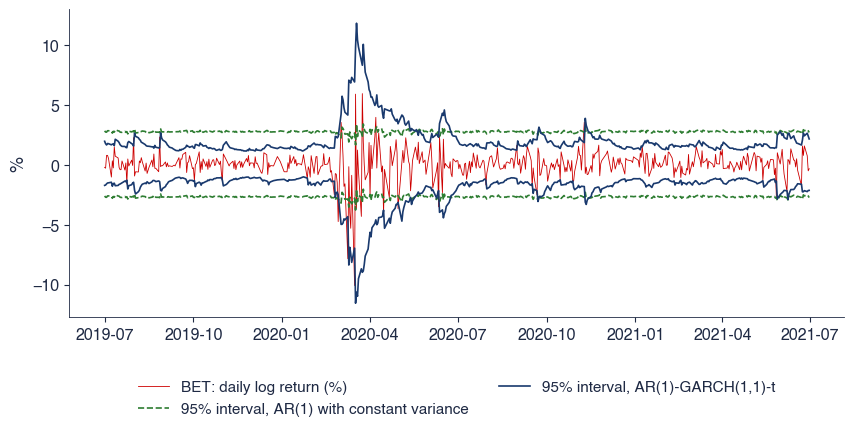

{'sd_const': 1.3892495245390717, 'out_c': 0.050232418653471285, 'out_g': 0.05158194631878842, 'out_c_calm2017': 0.004032258064516129, 'out_c_covid': 0.3333333333333333, 'out_g_calm2017': 0.020161290322580645, 'out_g_covid': 0.09523809523809523, 'w_c': 5.445858136193161, 'w_g_min': 2.179948678115946, 'w_g_max': 22.483738603725726}


In [12]:
def arma_garch_table(names=ASSETS):
    """AR(1) mean: OLS with constant variance against AR(1)-GARCH(1,1)-t (robust SE); Ljung-Box Q(10) of the
    standardised residuals with a constant mean and with the AR(1) mean; BIC of both GARCH-t models."""
    out = {}
    for k in names:
        r = returns(k)
        o = ols_ar1(r)
        rc, ra = fit(r, dist='t'), fit(r, mean='AR', dist='t')
        ph = [n for n in ra.params.index if n.endswith('[1]') and n not in ('alpha[1]', 'beta[1]')][0]
        sc_, sa_ = summary(rc, r), summary(ra, r)
        out[k] = {'p_bic': int(ar_order(r)[0]), 'phi_ols': o['phi'], 'se_ols': o['se'], 'phi_g': float(ra.params[ph]),
                  'se_g': float(ra.std_err[ph]), 't_g': float(ra.tvalues[ph]),
                  'lbz_c': ljung_box(rc.std_resid.dropna()), 'lbz_a': ljung_box(ra.std_resid.dropna(), dof=1),
                  'bic_c': sc_['bic'], 'bic_a': sa_['bic'], 'pers_a': sa_['pers'], 'nu_a': float(ra.params['nu'])}
    return out


def fig_bands(k='bet', a='2019-07-01', b='2021-06-30', save_it=True):
    """One-day-ahead 95% intervals for the BET return: AR(1) with constant variance (fixed width) against
    AR(1)-GARCH(1,1)-t (width that follows the conditional volatility); share of returns outside each band."""
    r = returns(k)
    o = ols_ar1(r)
    s = float(np.std(o['resid'], ddof=2))
    m_ols = o['c'] + o['phi'] * r.shift(1)
    lo_c, hi_c = m_ols - 1.96 * s, m_ols + 1.96 * s
    res = fit(r, mean='AR', dist='t')
    p = par(res)
    ph = [n for n in p.index if n.endswith('[1]') and n not in ('alpha[1]', 'beta[1]')][0]
    nu = p['nu']
    q = stats.t.ppf(0.975, nu) * np.sqrt((nu - 2) / nu)
    m_g = p['Const'] + p[ph] * r.shift(1)
    sg = sig(res)
    lo_g, hi_g = m_g - q * sg, m_g + q * sg
    out_c = ((r < lo_c) | (r > hi_c)).iloc[1:]
    out_g = ((r < lo_g) | (r > hi_g)).iloc[1:]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    w = slice(a, b)
    ax.plot(r.loc[w].index, r.loc[w], color=COLORS[k], lw=0.6, label=f'{NAME[k]}: daily log return (%)')
    ax.plot(lo_c.loc[w].index, lo_c.loc[w], color=st.Forest, lw=1.2, ls='--', label='95% interval, AR(1) with constant variance')
    ax.plot(hi_c.loc[w].index, hi_c.loc[w], color=st.Forest, lw=1.2, ls='--', label='_')
    ax.plot(lo_g.loc[w].index, lo_g.loc[w], color=st.MainBlue, lw=1.2, label='95% interval, AR(1)-GARCH(1,1)-t')
    ax.plot(hi_g.loc[w].index, hi_g.loc[w], color=st.MainBlue, lw=1.2, label='_')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    save('tsa_ch5_bands', save_it)
    yrs = {'calm2017': ('2017-01-01', '2017-12-31'), 'covid': ('2020-03-01', '2020-04-30')}
    return {'sd_const': s, 'out_c': float(out_c.mean()), 'out_g': float(out_g.mean()),
            **{f'out_c_{y}': float(out_c.loc[u:v].mean()) for y, (u, v) in yrs.items()},
            **{f'out_g_{y}': float(out_g.loc[u:v].mean()) for y, (u, v) in yrs.items()},
            'w_c': float(2 * 1.96 * s), 'w_g_min': float((hi_g - lo_g).loc[w].min()), 'w_g_max': float((hi_g - lo_g).loc[w].max())}


AG = arma_garch_table()
display(pd.DataFrame({k: {'p (BIC)': v['p_bic'], 'phi OLS': v['phi_ols'], 'SE OLS': v['se_ols'], 'phi AR-GARCH': v['phi_g'], 'SE AR-GARCH': v['se_g'], 'Q(10) z, AR(1)': v['lbz_a'][0]} for k, v in AG.items()}).T.round(3))
print(fig_bands(save_it=False))

## 7. Asymmetry

- News impact curves; GJR and EGARCH on four series; the sign-bias test.

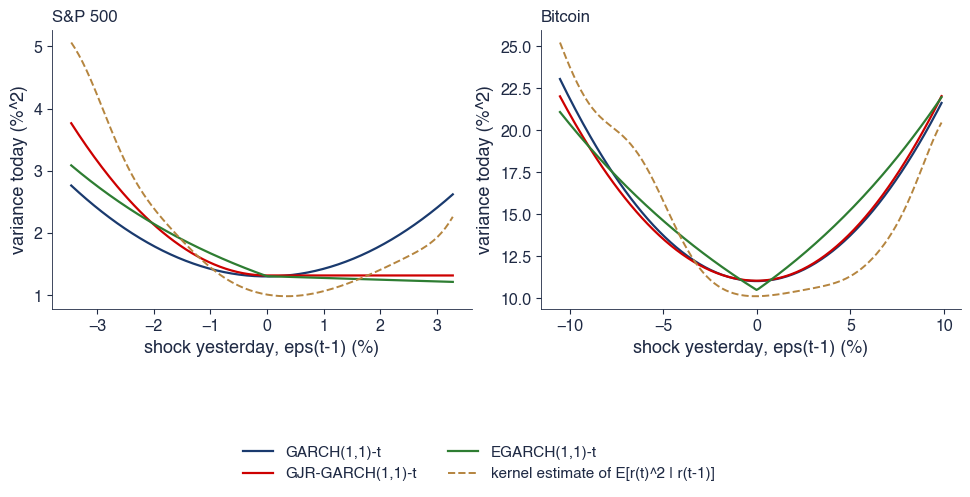

{'sp500': {'ratio_gjr': 1.6242323039138316, 'h': 0.6065141763352633}, 'btc': {'ratio_gjr': 0.9953121592606824, 'h': 1.7420823202296205}}


,GJR alpha,GJR gamma,t,LR,p,EGARCH gamma,sign bias
sp500,0.000,0.205,10.028,235.653,0.000,-0.165,40.665
bet,0.172,0.043,2.051,4.926,0.026,-0.028,11.637
eurron,0.103,0.039,3.031,9.293,0.002,-0.040,1.889
btc,0.113,-0.013,-0.721,0.662,0.416,0.015,1.269


In [13]:
def kernel_nic(r, grid, h=None):
    """Nadaraya-Watson estimate of E[r_t^2 | r_{t-1} = x] with a Gaussian kernel; bandwidth half a standard
    deviation of the returns."""
    x, y = r.values[:-1], r.values[1:] ** 2
    h = h or 0.5 * np.std(x)
    w = stats.norm.pdf((grid[:, None] - x[None, :]) / h)
    return (w * y).sum(1) / w.sum(1), h


def fig_nic(names=('sp500', 'btc'), save_it=True):
    """News impact curves of GARCH-t, GJR-t and EGARCH-t and a kernel estimate, for two series."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
    out = {}
    for ax, k in zip(axes, names):
        r = returns(k)
        s2bar = float(r.var())
        lo, hi = np.quantile(r, [0.01, 0.99])
        g = np.linspace(lo, hi, 201)
        for vol, o, lab, c in [('GARCH', 0, 'GARCH(1,1)-t', st.MainBlue), ('GARCH', 1, 'GJR-GARCH(1,1)-t', st.IDAred),
                               ('EGARCH', 0, 'EGARCH(1,1)-t', st.Forest)]:
            ax.plot(g, news_impact(fit(r, vol=vol, o=o, dist='t'), g, s2bar), color=c, lw=1.6, label=lab)
        kn, h = kernel_nic(r, g)
        ax.plot(g, kn, color=st.Amber, lw=1.4, ls='--', label='kernel estimate of E[r(t)^2 | r(t-1)]')
        ax.set_title(NAME[k], loc='left', fontsize=12)
        ax.set_xlabel('shock yesterday, eps(t-1) (%)')
        ax.set_ylabel('variance today (%^2)')
        rg = fit(r, o=1, dist='t')
        out[k] = {'ratio_gjr': float(news_impact(rg, np.array([-2.0]), s2bar)[0] / news_impact(rg, np.array([2.0]), s2bar)[0]),
                  'h': float(h)}
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    save('tsa_ch5_nic', save_it)
    return out


def asym_table(names=ASSETS):
    """GJR-GARCH(1,1)-t and EGARCH(1,1)-t: gamma with its robust t statistic, the likelihood-ratio test of GJR against
    GARCH, BIC, and the sign-bias test on the GARCH-t residuals."""
    out = {}
    for k in names:
        r = returns(k)
        rg, rj, re_ = fit(r, dist='t'), fit(r, o=1, dist='t'), fit(r, vol='EGARCH', dist='t')
        lr = 2 * (rj.loglikelihood - rg.loglikelihood)
        out[k] = {'gjr_gamma': float(rj.params['gamma[1]']), 'gjr_t': float(rj.tvalues['gamma[1]']),
                  'gjr_alpha': float(rj.params['alpha[1]']), 'gjr_beta': float(rj.params['beta[1]']),
                  'gjr_pers': persistence(rj), 'lr': float(lr), 'lr_p': float(stats.chi2.sf(lr, 1)),
                  'eg_gamma': float(re_.params['gamma[1]']), 'eg_t': float(re_.tvalues['gamma[1]']),
                  'eg_beta': float(re_.params['beta[1]']), 'sb': sign_bias_test(rg.std_resid, rg.resid),
                  'bic_g': float(rg.bic), 'bic_j': float(rj.bic), 'bic_e': float(re_.bic)}
    return out


print(fig_nic(save_it=False))
AS = asym_table()
display(pd.DataFrame({k: {'GJR alpha': v['gjr_alpha'], 'GJR gamma': v['gjr_gamma'], 't': v['gjr_t'], 'LR': v['lr'], 'p': v['lr_p'], 'EGARCH gamma': v['eg_gamma'], 'sign bias': v['sb']['joint']} for k, v in AS.items()}).T.round(3))

## 8. Diagnostics and model choice

- Standardised residuals; the EUR/RON day of 6 May 2025; nine models by BIC.

{'r': (96.26294643822116, 3.041604310685084e-16), 'r2': (6132.817239087847, 0.0), 'archlm_r': {'lm': 1683.8597480140716, 'r2': 0.25098520614310205, 'n': 6709, 'p': 0.0, 'crit': 11.070497693516351, 'b': [0.43969925081177197, 0.14501328141409797, 0.29524812666974243, 0.007129332305520464, 0.09292085175475855, 0.15968111422380854]}, 'normal': {'z': (21.198333015390183, 0.01975224870824878), 'z2': (16.396025134533204, 0.08884310339354372), 'archlm': {'lm': 6.988392380735451, 'r2': 0.001041644415074594, 'n': 6709, 'p': 0.2215050137919659, 'crit': 11.070497693516351, 'b': [0.9717706993862578, -0.010448445698646332, 0.013347280518209532, 0.0034294105690085997, 0.02625035025604834, -0.006345926549317749]}}, 't': {'z': (21.858114862057924, 0.01584395893404898), 'z2': (13.610348630216418, 0.19151799821764812), 'archlm': {'lm': 4.822367340999452, 'r2': 0.0007187907796988302, 'n': 6709, 'p': 0.4379412791155406, 'crit': 11.070497693516351, 'b': [0.980960621383678, -0.008060352366673764, 0.008963410

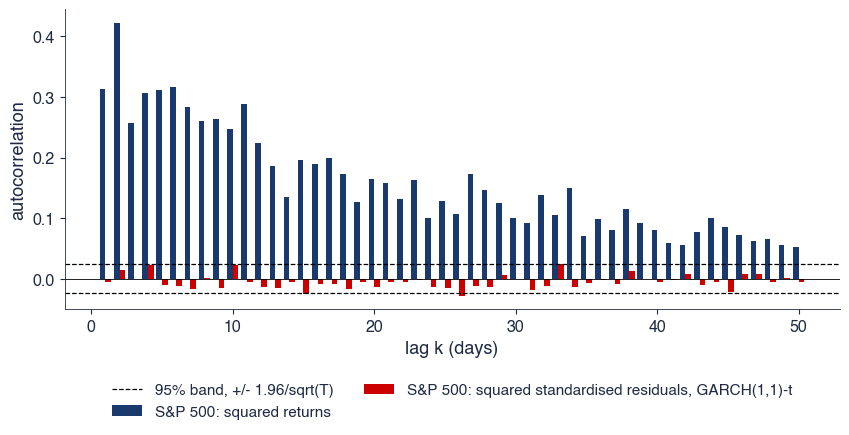

{'date': '2025-05-06', 'z': 153.71868430544455, 'r': 1.2041721893232493, 'sig_before': 0.00782880019064016, 'r_next': 1.2094574719831552, 'mean_abs_month': 0.003817324629064034, 'z_second': 13.186760389958184, 'lb_z2': (0.0035516783608225883, 0.9999999999999999), 'lb_z2_wo': (19.20575980812256, 0.03772572396498989), 'ppy': 252.39741768883152}


,model,dist,k,loglik,aic,bic,d_aic,d_bic
0,GARCH,Normal,4,-9218.0,18444.0,18471.2,669.4,648.9
1,GARCH,t,5,-9062.5,18134.9,18169.0,360.3,346.7
2,GARCH,skewed t,6,-9038.4,18088.9,18129.7,314.2,307.4
3,GJR,Normal,5,-9086.5,18183.0,18217.1,408.4,394.7
4,GJR,t,6,-8944.6,17901.3,17942.2,126.7,119.9
5,GJR,skewed t,7,-8905.1,17824.3,17871.9,49.6,49.6
6,EGARCH,Normal,5,-9075.6,18161.1,18195.2,386.5,372.9
7,EGARCH,t,6,-8922.1,17856.2,17897.1,81.6,74.8
8,EGARCH,skewed t,7,-8880.3,17774.6,17822.3,0.0,0.0


In [14]:
def diagnostics(k='sp500'):
    """Ljung-Box Q(10) of r, r^2, z, z^2 and ARCH-LM(5) of r and z, for GARCH-N and GARCH-t."""
    r = returns(k)
    out = {'r': ljung_box(r), 'r2': ljung_box(r ** 2), 'archlm_r': arch_lm(r.values)}
    for d in ['normal', 't']:
        z = fit(r, dist=d).std_resid.dropna()
        out[d] = {'z': ljung_box(z), 'z2': ljung_box(z ** 2), 'archlm': arch_lm(z.values)}
    return out


def diag_markets(names=ASSETS):
    """Ljung-Box Q(10) of r^2 and of z (GARCH-t) and z^2 for each series."""
    out = {}
    for k in names:
        r = returns(k)
        z = fit(r, dist='t').std_resid.dropna()
        out[k] = {'r2': ljung_box(r ** 2), 'z2': ljung_box(z ** 2), 'z': ljung_box(z), 'lm_z': arch_lm(z.values)}
    return out


def fig_acf_diag(k='sp500', nlags=50, save_it=True):
    """ACF of squared returns and of squared standardised residuals (GARCH-t), with the 95% band."""
    r = returns(k)
    z = fit(r, dist='t').std_resid.dropna()
    a1, a2 = acf_vals(r ** 2, nlags), acf_vals(z ** 2, nlags)
    lags = np.arange(1, nlags + 1)
    band = 1.96 / np.sqrt(len(r))
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.bar(lags - 0.2, a1, width=0.4, color=COLORS[k], label=f'{NAME[k]}: squared returns')
    ax.bar(lags + 0.2, a2, width=0.4, color=st.IDAred, label=f'{NAME[k]}: squared standardised residuals, GARCH(1,1)-t')
    ax.axhline(band, color='black', ls='--', lw=0.9, label='95% band, +/- 1.96/sqrt(T)')
    ax.axhline(-band, color='black', ls='--', lw=0.9)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('lag k (days)')
    ax.set_ylabel('autocorrelation')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('tsa_ch5_acf_diag', save_it)
    return {'a1_1': float(a1[0]), 'a1_50': float(a1[-1]), 'a2_1': float(a2[0]), 'max_a2': float(np.max(np.abs(a2))),
            'band': float(band)}


def managed_rate_case(k='eurron', a='2025-04-01', b='2025-04-30'):
    """EUR/RON, GARCH(1,1)-t: the largest standardised residual (6 May 2025 after a calm month), the conditional
    volatility the day before, and the Ljung-Box Q(10) of z^2 with and without that day."""
    r = returns(k)
    res = fit(r, dist='t')
    z = res.std_resid.dropna()
    d = z.abs().idxmax()
    v = sig(res)
    i = r.index.get_loc(d)
    return {'date': d.date().isoformat(), 'z': float(z.loc[d]), 'r': float(r.loc[d]), 'sig_before': float(v.iloc[i]),
            'r_next': float(r.iloc[i + 1]), 'mean_abs_month': float(r.loc[a:b].abs().mean()),
            'z_second': float(z.abs().sort_values().iloc[-2]), 'lb_z2': ljung_box(z ** 2), 'lb_z2_wo': ljung_box((z ** 2).drop(d)),
            'ppy': float(periods_per_year(r))}


def model_selection(k='sp500'):
    """Nine models (GARCH, GJR, EGARCH x Normal, t, skewed t): log-likelihood, number of parameters, AIC, BIC."""
    r = returns(k)
    rows = []
    for vol, o, vlab in [('GARCH', 0, 'GARCH'), ('GARCH', 1, 'GJR'), ('EGARCH', 0, 'EGARCH')]:
        for d, dlab in [('normal', 'Normal'), ('t', 't'), ('skewt', 'skewed t')]:
            res = fit(r, vol=vol, o=o, dist=d)
            rows.append({'model': vlab, 'dist': dlab, 'k': int(len(res.params)), 'loglik': float(res.loglikelihood),
                         'aic': float(res.aic), 'bic': float(res.bic)})
    df = pd.DataFrame(rows)
    df['d_aic'] = df['aic'] - df['aic'].min()
    df['d_bic'] = df['bic'] - df['bic'].min()
    return df


print(diagnostics())
fig_acf_diag(save_it=False)
print(managed_rate_case())
display(model_selection().round(1))

## 9. Forecasts, their evaluation and VaR 1%

- The term structure of volatility; GARCH-t, GJR-t and EWMA out of sample (QLIKE, Diebold–Mariano); VaR 1% exceedances.

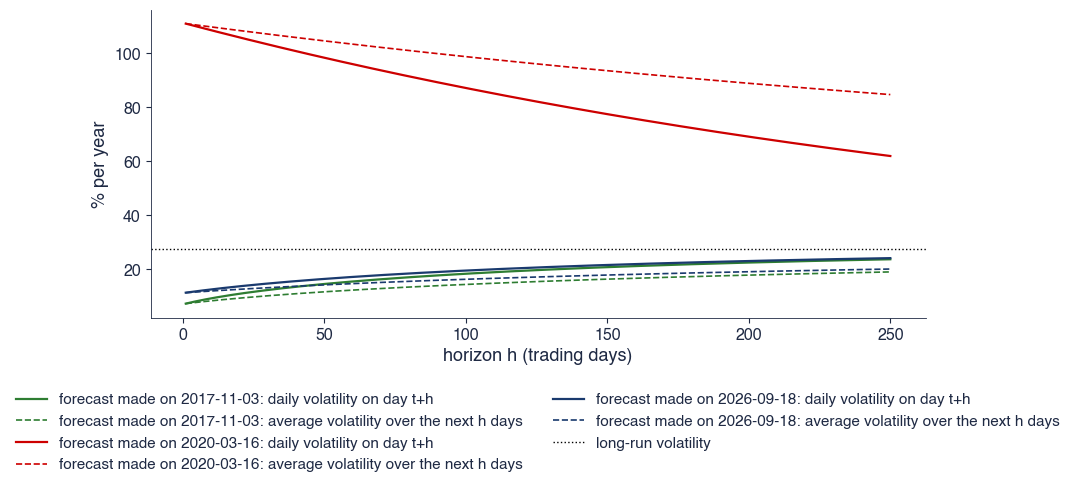

,QLIKE GARCH-t,QLIKE GJR-t,QLIKE EWMA,DM t,VaR 1% exc. GARCH-t (%),VaR 1% exc. EWMA (%)
sp500,0.761,0.733,0.819,-3.689,1.664,2.208
bet,0.680,0.674,0.788,-2.218,1.162,2.290
eurron,2.456,3.276,5.982,-1.016,1.191,2.144
btc,3.383,3.401,3.390,-0.195,1.496,2.173


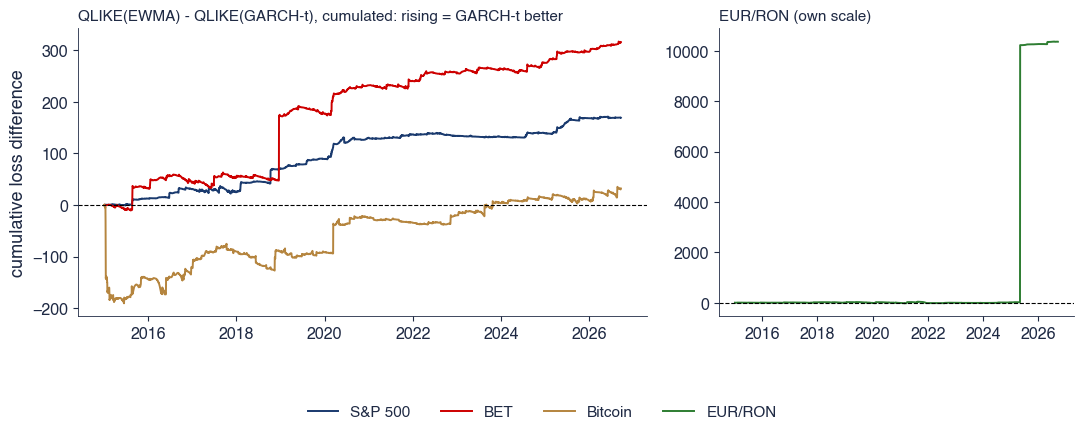

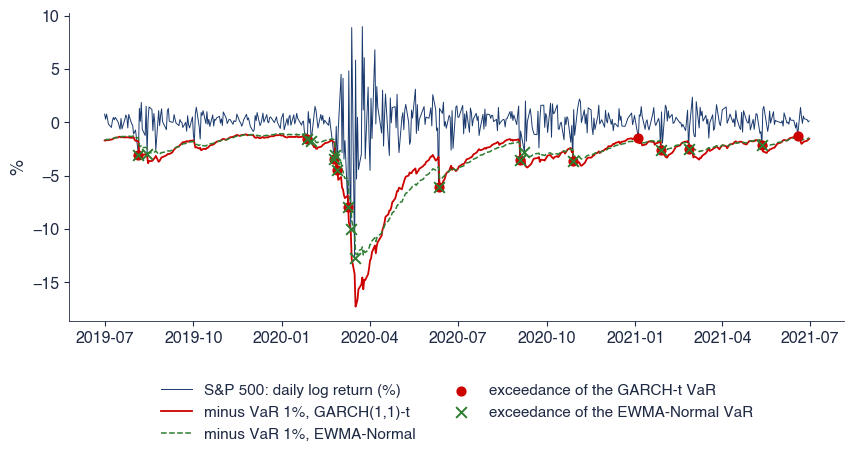

{'n': 505, 'exc_garch': 13, 'exc_ewma': 17}

In [15]:
def garch_path_forecast(res, r, date, horizon=250):
    """Multi-step GARCH(1,1) variance forecasts (in %^2) made at the end of `date`:
    sigma^2_{t+h} = s2bar + (alpha + beta)^(h-1) (sigma^2_{t+1} - s2bar), s2bar = omega / (1 - alpha - beta)."""
    p = par(res)
    pers = p['alpha[1]'] + p['beta[1]']
    s2bar = p['omega'] / (1 - pers)
    i = r.index.get_loc(pd.Timestamp(date))
    s2t = sig(res).iloc[i] ** 2
    e = r.iloc[i] - p['mu']
    s2next = p['omega'] + p['alpha[1]'] * e ** 2 + p['beta[1]'] * s2t
    h = np.arange(1, horizon + 1)
    return s2bar + pers ** (h - 1) * (s2next - s2bar), s2bar, s2next


def fig_term_structure(k='sp500', horizon=250, save_it=True):
    """Forecasts of the daily volatility h days ahead (annualised) and of the average volatility over the next h days,
    made on a calm day, at the COVID-19 peak and on the last day of the data."""
    r = returns(k)
    res = fit(r, dist='t')
    ann = periods_per_year(r)
    dates = TERM_DATES + [r.index[-1].date().isoformat()]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    h = np.arange(1, horizon + 1)
    for d, c in zip(dates, [st.Forest, st.IDAred, st.MainBlue]):
        f, s2bar, s2n = garch_path_forecast(res, r, d, horizon)
        avg = np.sqrt(np.cumsum(f) / h * ann)
        ax.plot(h, np.sqrt(f * ann), color=c, lw=1.6, label=f'forecast made on {d}: daily volatility on day t+h')
        ax.plot(h, avg, color=c, lw=1.2, ls='--', label=f'forecast made on {d}: average volatility over the next h days')
        out[d] = {'h1': float(np.sqrt(f[0] * ann)), 'h10': float(np.sqrt(f[9] * ann)), 'h22': float(np.sqrt(f[21] * ann)),
                  'h250': float(np.sqrt(f[-1] * ann)), 'avg10': float(avg[9]), 'avg22': float(avg[21]), 'avg250': float(avg[-1]),
                  's2next': float(s2n), 'sum10': float(np.sum(f[:10]))}
    ax.axhline(np.sqrt(s2bar * ann), color='black', ls=':', lw=1.0, label='long-run volatility')
    ax.set_xlabel('horizon h (trading days)')
    ax.set_ylabel('% per year')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('tsa_ch5_term_structure', save_it)
    out['lr'] = float(np.sqrt(s2bar * ann))
    out['s2bar'] = float(s2bar)
    out['params'] = {n: float(v) for n, v in par(res).items()}
    return out


def forecast_eval(names=ASSETS):
    """Mean QLIKE of GARCH-t, GJR-t and EWMA; DM tests against EWMA; VaR 1% exceedance rates."""
    out, frames = {}, {}
    for k in names:
        df = oos_forecasts(k)
        frames[k] = df
        px = df['r'] ** 2
        L = {m: qlike(px, df[m]) for m in ['garch', 'gjr', 'ewma']}
        eg, ee = df['r'] < -df['var_garch'], df['r'] < -df['var_ewma']
        out[k] = {'n': len(df), 'first': df.index[0].date().isoformat(),
                  'qlike': {m: float(v.mean()) for m, v in L.items()},
                  'dm_garch_ewma': dm_test(L['garch'], L['ewma']), 'dm_gjr_garch': dm_test(L['gjr'], L['garch']),
                  'exc_garch': float(eg.mean()), 'exc_ewma': float(ee.mean()),
                  'nexc_garch': int(eg.sum()), 'nexc_ewma': int(ee.sum())}
    return out, frames


def fig_forecast_eval(frames, save_it=True):
    """Cumulative QLIKE difference EWMA minus GARCH-t on the out-of-sample period (rising: GARCH-t better); EUR/RON
    in its own panel, since a few days with a near-zero EWMA forecast dominate its scale."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={'width_ratios': [1.6, 1]})
    out = {}
    for k, df in frames.items():
        px = df['r'] ** 2
        dd = qlike(px, df['ewma']) - qlike(px, df['garch'])
        d = dd.cumsum()
        ax = axes[1] if k == 'eurron' else axes[0]
        ax.plot(d.index, d.values, color=COLORS[k], lw=1.4, label=f'{NAME[k]}')
        out[k] = {'total': float(d.iloc[-1]), 'max_day': dd.idxmax().date().isoformat(), 'max_val': float(dd.max()),
                  'share_max': float(dd.max() / d.iloc[-1]) if d.iloc[-1] != 0 else float('nan')}
    for ax in axes:
        ax.axhline(0, color='black', lw=0.8, ls='--')
    axes[0].set_ylabel('cumulative loss difference')
    axes[0].set_title('QLIKE(EWMA) - QLIKE(GARCH-t), cumulated: rising = GARCH-t better', loc='left', fontsize=11)
    axes[1].set_title('EUR/RON (own scale)', loc='left', fontsize=11)
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch5_forecast_eval', save_it)
    return out


def fig_var(frames, k='sp500', a='2019-07-01', b='2021-06-30', save_it=True):
    """Daily returns with the one-day VaR 1% of GARCH-t and of EWMA-Normal, and the exceedances."""
    df = frames[k].loc[a:b]
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(df.index, df['r'], color=COLORS[k], lw=0.7, label=f'{NAME[k]}: daily log return (%)')
    ax.plot(df.index, -df['var_garch'], color=st.IDAred, lw=1.3, label='minus VaR 1%, GARCH(1,1)-t')
    ax.plot(df.index, -df['var_ewma'], color=st.Forest, lw=1.1, ls='--', label='minus VaR 1%, EWMA-Normal')
    e1, e2 = df['r'] < -df['var_garch'], df['r'] < -df['var_ewma']
    ax.scatter(df.index[e1], df['r'][e1], color=st.IDAred, s=40, marker='o', zorder=5, label='exceedance of the GARCH-t VaR')
    ax.scatter(df.index[e2], df['r'][e2], color=st.Forest, s=60, marker='x', zorder=6, label='exceedance of the EWMA-Normal VaR')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    save('tsa_ch5_var', save_it)
    return {'n': int(len(df)), 'exc_garch': int(e1.sum()), 'exc_ewma': int(e2.sum())}


fig_term_structure(save_it=False)
fe, frames = forecast_eval()
display(pd.DataFrame({k: {'QLIKE GARCH-t': v['qlike']['garch'], 'QLIKE GJR-t': v['qlike']['gjr'], 'QLIKE EWMA': v['qlike']['ewma'], 'DM t': v['dm_garch_ewma']['t'], 'VaR 1% exc. GARCH-t (%)': 100 * v['exc_garch'], 'VaR 1% exc. EWMA (%)': 100 * v['exc_ewma']} for k, v in fe.items()}).T.round(3))
fig_forecast_eval(frames, save_it=False)
fig_var(frames, save_it=False)

## Exercises

1. Estimate GARCH(1,1)-t for the DAX (`returns('dax')`, after adding `'dax'` to `START`) and compare its persistence with the S&P 500.
2. Re-estimate the S&P 500 GARCH(1,1)-t on 2000–2012 and on 2013–2026: is the persistence stable?
3. Change `LAMBDA` to 0.97 and repeat the out-of-sample comparison: does EWMA improve?